## **import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression, Ridge, RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score, GridSearchCV


## **load dataset**

In [2]:
df = pd.read_csv("C:\\Users\\ePadd\\OneDrive - University of Ghana\\Documents\\DATA SCIENCE\\AI_ML\\PROJECTS\\machine_learning_zoomcamp\\data\\data.csv")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## **EDA**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [4]:
df.shape

(11914, 16)

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [7]:
list[df.dtypes[df.dtypes == 'object'].index]

list[Index(['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'],
      dtype='object')]

In [8]:
strings = ['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']      


In [9]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [10]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [11]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [12]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values\n")

make: 48 unique values

model: 914 unique values

year: 28 unique values

engine_fuel_type: 10 unique values

engine_hp: 356 unique values

engine_cylinders: 9 unique values

transmission_type: 5 unique values

driven_wheels: 4 unique values

number_of_doors: 3 unique values

market_category: 71 unique values

vehicle_size: 3 unique values

vehicle_style: 16 unique values

highway_mpg: 59 unique values

city_mpg: 69 unique values

popularity: 48 unique values

msrp: 6049 unique values



In [13]:
for col in df.columns:
    print(f"{col}: {df[col].unique()[:5]}\n")

make: ['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']

model: ['1_series_m' '1_series' '100' '124_spider' '190-class']

year: [2011 2012 2013 1992 1993]

engine_fuel_type: ['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']

engine_hp: [335. 300. 230. 320. 172.]

engine_cylinders: [ 6.  4.  5.  8. 12.]

transmission_type: ['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']

driven_wheels: ['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']

number_of_doors: [ 2.  4.  3. nan]

market_category: ['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']

vehicle_size: ['compact' 'midsize' 'large']

vehicle_style: ['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']

highway_mpg: [26 28 27 25 24]

city_mpg: [19 20 18 17 16]

popularity: [3916 3105  819  617 1013]

msrp: [46135 40650 36350 29450 34500]



## **distribution of msrp(price of cars)**

<Axes: xlabel='msrp', ylabel='Count'>

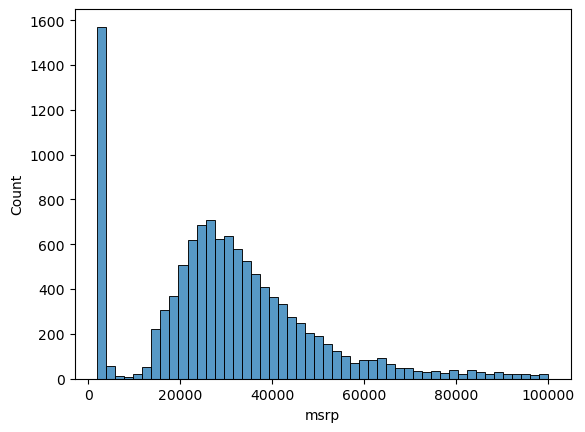

In [14]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

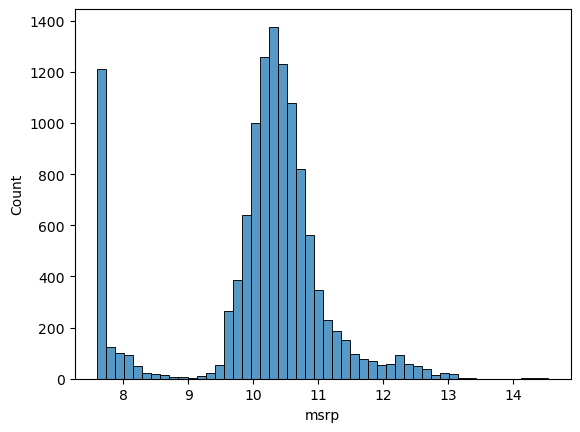

In [15]:
sns.histplot(np.log(df.msrp), bins=50) # took log of msrp to scale them down

## **check missing values**

In [16]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## **feature selection**

In [17]:
df_1 = df.copy()

In [18]:
# df_ =df_1[['engine_hp', 'engine_cylinders', 'year',
#        'highway_mpg', 'city_mpg', 'popularity', 'msrp']]

In [19]:
df_1.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [20]:
df_1.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [21]:
df_1 = df_1.fillna(0)

In [22]:
df_1.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

In [23]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  object 
 1   model              11914 non-null  object 
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11914 non-null  object 
 4   engine_hp          11914 non-null  float64
 5   engine_cylinders   11914 non-null  float64
 6   transmission_type  11914 non-null  object 
 7   driven_wheels      11914 non-null  object 
 8   number_of_doors    11914 non-null  float64
 9   market_category    11914 non-null  object 
 10  vehicle_size       11914 non-null  object 
 11  vehicle_style      11914 non-null  object 
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5

In [24]:
df_1.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

In [25]:
# msrp = df_1.drop(columns=['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
#        'engine_cylinders', 'transmission_type', 'driven_wheels',
#        'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
#        'highway_mpg', 'city_mpg', 'popularity'])

In [26]:
column = ['make', 'model', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity']

In [27]:
# df_predictors = df_1.drop(columns=['make', 'model', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
#        'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style'])

In [28]:
# df_predictors.dropna(inplace=True)

In [29]:
# df_predictors.isnull().sum()

In [30]:
# df_predictors.info()

In [31]:
# msrp = np.log(df_predictors['msrp'])
# msrp.head(5)

In [32]:
# df_predictors.head()

In [33]:
model_counts = df_1['model'].value_counts()
print(f"Total unique models: {len(model_counts)}")
print("\nTop 20 most common models:")
print(model_counts.head(20))
print(f"\nModels that appear only once: {(model_counts == 1).sum()}")

threshold = 50

rare_models = model_counts[model_counts < threshold].index
print(f"\nNumber of rare models (appear < {threshold} times): {len(rare_models)}")

df_1['model_grouped'] = df_1['model'].copy()
df_1.loc[df_1['model'].isin(rare_models), 'model_grouped'] = 'Other_Model'

new_model_counts = df_1['model_grouped'].value_counts()
print(f"\nNew unique models after grouping: {len(new_model_counts)}")
print("\nNew model distribution:")
print(new_model_counts.head(10))

thresholds = [10, 20, 50, 100, 200]
for thresh in thresholds:
    rare = model_counts[model_counts < thresh].index
    print(f"Threshold {thresh}: {len(rare)} rare models, would create ~{len(model_counts) - len(rare) + 1} columns")

Total unique models: 914

Top 20 most common models:
model
silverado_1500        156
tundra                140
f-150                 126
sierra_1500            90
beetle_convertible     89
tacoma                 80
gti                    76
frontier               76
accord                 75
beetle                 75
civic                  68
dakota                 65
ram_pickup_1500        62
jetta                  61
corvette               60
911                    58
c/k_1500_series        56
colorado               54
xc60                   54
3                      53
Name: count, dtype: int64

Models that appear only once: 40

Number of rare models (appear < 50 times): 891

New unique models after grouping: 24

New model distribution:
model_grouped
Other_Model           10188
silverado_1500          156
tundra                  140
f-150                   126
sierra_1500              90
beetle_convertible       89
tacoma                   80
frontier                 76
gti         

In [34]:
df_1.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,model_grouped
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135,Other_Model
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650,Other_Model
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350,Other_Model
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450,Other_Model
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500,Other_Model


## **train test validation**

In [35]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df_1.drop(columns=['msrp']), np.log(df_1.msrp), test_size=0.4, random_state=24
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=24
)

print(f"Train X:", X_train.shape, "Train y:", y_train.shape)
print(f"Validation X:", X_val.shape, "Validation y:", y_val.shape)
print(f"Test X:", X_test.shape, "Test y:", y_test.shape)

Train X: (7148, 16) Train y: (7148,)
Validation X: (2383, 16) Validation y: (2383,)
Test X: (2383, 16) Test y: (2383,)


In [36]:
X_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,model_grouped
11217,hyundai,veloster,2014,regular_unleaded,132.0,4.0,automated_manual,front_wheel_drive,3.0,hatchback,compact,2dr_hatchback,36,28,1439,Other_Model
11486,bmw,x1,2016,premium_unleaded_(required),228.0,4.0,automatic,all_wheel_drive,4.0,"crossover,luxury",compact,4dr_suv,32,22,3916,Other_Model
5797,acura,ilx_hybrid,2014,premium_unleaded_(recommended),111.0,4.0,automatic,front_wheel_drive,4.0,"luxury,hybrid",compact,sedan,38,39,204,Other_Model
9337,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,24,18,549,sierra_1500
2287,gmc,canyon,2015,regular_unleaded,305.0,6.0,automatic,four_wheel_drive,4.0,0,compact,crew_cab_pickup,24,17,549,Other_Model


In [37]:
y_train[:5]

11217     9.854822
11486    10.457373
5797     10.451609
9337     10.482626
2287     10.517321
Name: msrp, dtype: float64

## **fit model**

In [38]:
lr_model = LinearRegression()

In [39]:
X_train_numeric = X_train.select_dtypes(include=['number'])
X_train_numeric.head()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity
11217,2014,132.0,4.0,3.0,36,28,1439
11486,2016,228.0,4.0,4.0,32,22,3916
5797,2014,111.0,4.0,4.0,38,39,204
9337,2015,285.0,6.0,4.0,24,18,549
2287,2015,305.0,6.0,4.0,24,17,549


In [40]:
lr_model.fit(X_train_numeric.drop(columns=['year']), y_train)

LinearRegression()

In [41]:
y_train_pred = lr_model.predict(X_train_numeric.drop(columns=['year']))
print(y_train_pred.shape)
print(y_train.shape)

(7148,)
(7148,)


## **distribution of actual vs predicted**

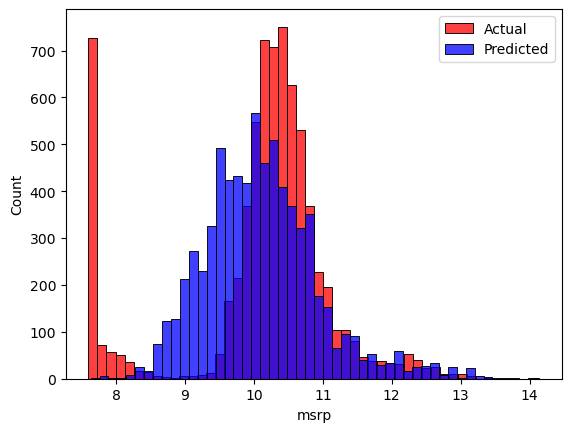

In [42]:
sns.histplot(y_train, bins = 50, color='red', label='Actual')
sns.histplot(y_train_pred, bins = 50, color='blue', label='Predicted')
plt.legend()

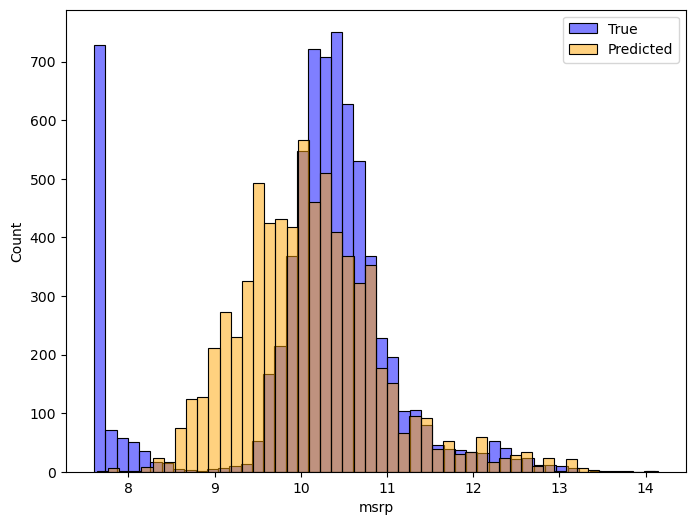

In [43]:
plt.figure(figsize=(8,6))

# Plot true values
sns.histplot((y_train),bins = 50, color='blue', label='True', alpha=0.5)

# Plot predicted values
sns.histplot((y_train_pred), bins = 50, color='orange', label='Predicted', alpha=0.5)

# plt.xlabel('MSRP')
# plt.ylabel('Density')
# plt.title('Distribution of True vs Predicted MSRP (Train Set)')
plt.legend()
plt.show()

## **rmse, r2**

In [44]:
def rmsee(y_true, y_train_pred):
    err = y_true - y_train_pred
    return np.sqrt(np.mean(err ** 2))

rmsee_train = rmsee(y_train, y_train_pred)
print("Train RMSE:", rmsee_train)

Train RMSE: 0.7290851445414753


In [45]:

rmse_train = np.sqrt(mean_squared_error(y_train_pred, y_train))
r2_train = r2_score(y_train, y_train_pred)

print("Train RMSE:",rmse_train)
print("Train R²:", r2_train)


Train RMSE: 0.7290851445414753
Train R²: 0.5641702555431058


In [46]:
y_val_pred = lr_model.predict(X_val.select_dtypes(include=['number']).drop(columns=['year']))

In [47]:
# Test metrics
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)

print("Test RMSE:", rmse_val)
print("Test R²:", r2_val)

Test RMSE: 0.7328297610128971
Test R²: 0.567394449342977


## **feature engineering**

In [48]:
def prepare_df(df):
    df["age"] = 2017 - df['year']
    return df


In [49]:
prepare_df(X_train)

X_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,model_grouped,age
11217,hyundai,veloster,2014,regular_unleaded,132.0,4.0,automated_manual,front_wheel_drive,3.0,hatchback,compact,2dr_hatchback,36,28,1439,Other_Model,3
11486,bmw,x1,2016,premium_unleaded_(required),228.0,4.0,automatic,all_wheel_drive,4.0,"crossover,luxury",compact,4dr_suv,32,22,3916,Other_Model,1
5797,acura,ilx_hybrid,2014,premium_unleaded_(recommended),111.0,4.0,automatic,front_wheel_drive,4.0,"luxury,hybrid",compact,sedan,38,39,204,Other_Model,3
9337,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,24,18,549,sierra_1500,2
2287,gmc,canyon,2015,regular_unleaded,305.0,6.0,automatic,four_wheel_drive,4.0,0,compact,crew_cab_pickup,24,17,549,Other_Model,2


In [50]:
# X_val_numeric = X_val.select_dtypes(include=['number'])

prepare_df(X_val)

X_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,model_grouped,age
6636,dodge,magnum,2006,regular_unleaded,190.0,6.0,automatic,rear_wheel_drive,4.0,0,large,wagon,26,18,1851,Other_Model,11
8519,kia,rio,2016,regular_unleaded,138.0,4.0,automatic,front_wheel_drive,4.0,0,compact,sedan,37,27,1720,Other_Model,1
9806,gmc,sonoma,2003,regular_unleaded,190.0,6.0,manual,four_wheel_drive,3.0,0,compact,extended_cab_pickup,17,12,549,Other_Model,14
2017,oldsmobile,bravada,2004,regular_unleaded,275.0,6.0,automatic,all_wheel_drive,4.0,0,midsize,4dr_suv,19,14,26,Other_Model,13
4230,suzuki,esteem,2001,regular_unleaded,122.0,4.0,manual,front_wheel_drive,4.0,0,compact,wagon,32,24,481,Other_Model,16


In [51]:
# X_test_numeric = X_test.select_dtypes(include=['number'])

prepare_df(X_test)

X_test.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,model_grouped,age
9416,oldsmobile,silhouette,2002,regular_unleaded,185.0,6.0,automatic,all_wheel_drive,4.0,0,midsize,passenger_minivan,22,16,26,Other_Model,15
6643,dodge,magnum,2007,premium_unleaded_(required),425.0,8.0,automatic,rear_wheel_drive,4.0,"factory_tuner,high-performance",large,wagon,18,13,1851,Other_Model,10
5628,volkswagen,gti,2012,premium_unleaded_(recommended),200.0,4.0,automated_manual,front_wheel_drive,4.0,"hatchback,performance",compact,4dr_hatchback,33,24,873,gti,5
8204,dodge,ram_van,1998,regular_unleaded,175.0,6.0,automatic,rear_wheel_drive,3.0,0,midsize,cargo_van,16,13,1851,Other_Model,19
9777,chevrolet,sonic,2016,regular_unleaded,138.0,4.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,34,27,1385,Other_Model,1


In [52]:
X_train.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
model_grouped        0
age                  0
dtype: int64

In [53]:
lr_model.fit(X_train.select_dtypes(include=['number']).drop(columns=['year']), y_train)

LinearRegression()

In [54]:
y_val_pred = lr_model.predict(X_val.select_dtypes(include=['number']).drop(columns=['year']))

In [55]:
# Test metrics
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)

print("Test RMSE:", rmse_val)
print("Test R²:", r2_val)

Test RMSE: 0.5219306261147263
Test R²: 0.7805621933002115


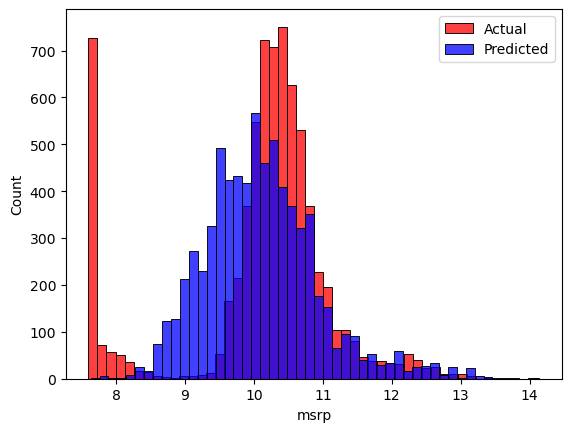

In [56]:
sns.histplot(y_train, bins = 50, color='red', label='Actual')
sns.histplot(y_train_pred, bins = 50, color='blue', label='Predicted')
plt.legend()

## **categorical variables**

In [57]:
X_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,model_grouped,age
11217,hyundai,veloster,2014,regular_unleaded,132.0,4.0,automated_manual,front_wheel_drive,3.0,hatchback,compact,2dr_hatchback,36,28,1439,Other_Model,3
11486,bmw,x1,2016,premium_unleaded_(required),228.0,4.0,automatic,all_wheel_drive,4.0,"crossover,luxury",compact,4dr_suv,32,22,3916,Other_Model,1
5797,acura,ilx_hybrid,2014,premium_unleaded_(recommended),111.0,4.0,automatic,front_wheel_drive,4.0,"luxury,hybrid",compact,sedan,38,39,204,Other_Model,3
9337,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,24,18,549,sierra_1500,2
2287,gmc,canyon,2015,regular_unleaded,305.0,6.0,automatic,four_wheel_drive,4.0,0,compact,crew_cab_pickup,24,17,549,Other_Model,2


In [58]:
print(X_train.number_of_doors.unique())
print(X_val.number_of_doors.unique())
print(X_test.number_of_doors.unique())

[3. 4. 2. 0.]
[4. 3. 2.]
[4. 3. 2. 0.]


In [59]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7148 entries, 11217 to 899
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               7148 non-null   object 
 1   model              7148 non-null   object 
 2   year               7148 non-null   int64  
 3   engine_fuel_type   7148 non-null   object 
 4   engine_hp          7148 non-null   float64
 5   engine_cylinders   7148 non-null   float64
 6   transmission_type  7148 non-null   object 
 7   driven_wheels      7148 non-null   object 
 8   number_of_doors    7148 non-null   float64
 9   market_category    7148 non-null   object 
 10  vehicle_size       7148 non-null   object 
 11  vehicle_style      7148 non-null   object 
 12  highway_mpg        7148 non-null   int64  
 13  city_mpg           7148 non-null   int64  
 14  popularity         7148 non-null   int64  
 15  model_grouped      7148 non-null   object 
 16  age                7148 no

In [60]:
categorical_features = ['make', 'engine_fuel_type', 'transmission_type', 
                        'driven_wheels', 'number_of_doors', 'market_category', 
                        'vehicle_size', 'vehicle_style', 'model_grouped']



In [61]:
# prepare_df(X_train)
# prepare_df(X_val)
# prepare_df(X_test)

In [62]:
X_train = pd.get_dummies(
    X_train,
    columns = categorical_features,
    drop_first=True,
    dtype=int
)

X_val = pd.get_dummies(
    X_val,
    columns = categorical_features,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns = categorical_features,
    drop_first=True,
    dtype=int
)

In [63]:
X_train.drop(columns=['model', 'year'], inplace=True)
X_val.drop(columns=['model', 'year'], inplace=True)
X_test.drop(columns=['model', 'year'], inplace=True)

In [64]:
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [65]:
print(X_val.shape[1])
print(X_train.shape[1])
print(X_test.shape[1])

182
182
182


In [66]:
X_train.head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity,age,make_alfa_romeo,make_aston_martin,make_audi,make_bentley,...,model_grouped_golf_gti,model_grouped_gti,model_grouped_jetta,model_grouped_ram_pickup_1500,model_grouped_sienna,model_grouped_sierra_1500,model_grouped_silverado_1500,model_grouped_tacoma,model_grouped_tundra,model_grouped_xc60
11217,132.0,4.0,36,28,1439,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11486,228.0,4.0,32,22,3916,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5797,111.0,4.0,38,39,204,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9337,285.0,6.0,24,18,549,2,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2287,305.0,6.0,24,17,549,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
X_val.select_dtypes(include=['number']).head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity,age,make_alfa_romeo,make_aston_martin,make_audi,make_bentley,...,model_grouped_golf_gti,model_grouped_gti,model_grouped_jetta,model_grouped_ram_pickup_1500,model_grouped_sienna,model_grouped_sierra_1500,model_grouped_silverado_1500,model_grouped_tacoma,model_grouped_tundra,model_grouped_xc60
6636,190.0,6.0,26,18,1851,11,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8519,138.0,4.0,37,27,1720,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9806,190.0,6.0,17,12,549,14,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017,275.0,6.0,19,14,26,13,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4230,122.0,4.0,32,24,481,16,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
X_test.select_dtypes(include=['number']).head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity,age,make_alfa_romeo,make_aston_martin,make_audi,make_bentley,...,model_grouped_golf_gti,model_grouped_gti,model_grouped_jetta,model_grouped_ram_pickup_1500,model_grouped_sienna,model_grouped_sierra_1500,model_grouped_silverado_1500,model_grouped_tacoma,model_grouped_tundra,model_grouped_xc60
9416,185.0,6.0,22,16,26,15,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6643,425.0,8.0,18,13,1851,10,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5628,200.0,4.0,33,24,873,5,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
8204,175.0,6.0,16,13,1851,19,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9777,138.0,4.0,34,27,1385,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [69]:
lr_model.fit(X_train, y_train)

LinearRegression()

In [70]:
y_train_pred = lr_model.predict(X_train)
y_train_pred[:5]

array([ 9.81046761, 10.69586378, 10.62221883, 10.42105779, 10.7283142 ])

In [71]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

print("Train RMSE:", rmse_train)
print("Train R²:", r2_train)

Train RMSE: 0.38527110884100313
Train R²: 0.8782992503012874


In [72]:
y_pred_val = lr_model.predict(X_val.select_dtypes(include=['number']))
y_pred_val[:5]

array([9.41084362, 9.96128429, 9.11509784, 9.49312171, 8.79055877])

In [73]:
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)

print("Validation RMSE:", rmse_val)
print("Validation R²:", r2_val)

Validation RMSE: 0.5219306261147263
Validation R²: 0.7805621933002115


In [74]:
y_pred_test = lr_model.predict(X_test.select_dtypes(include=['number']))
y_pred_test[:5]

array([ 9.20515403, 10.44152276, 10.09935348,  8.24458486, 10.07664439])

In [75]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("Test RMSE:", rmse_test)
print("Test R²:", r2_test)

Test RMSE: 0.46222674610953113
Test R²: 0.8238767908476607


## **Regularisation and handling categorical values**

In [76]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [98]:
lasso = Lasso(alpha=0.01)  # Start with small alpha
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.01)

In [99]:
lasso_test_pred = lasso.predict(X_test_scaled)
rmse_lasso_test = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

print("Lasso Test RMSE:", rmse_lasso_test)
print("R2:", r2_score(y_test, lasso_test_pred))


Lasso Test RMSE: 0.4147076276674158
R2: 0.85822799105729


In [100]:
feature_names = X_train.columns

coef = pd.DataFrame(
    {
    'feature': feature_names,
    'coefficient': lasso.coef_
}
)
coef['abs_coef'] = abs(coef['coefficient'])
coef = coef.sort_values('abs_coef', ascending=False)

coef.head(15)

,feature,coefficient,abs_coef
5,age,-0.744123,0.744123
0,engine_hp,0.181221,0.181221
2,highway_mpg,-0.114174,0.114174
60,engine_fuel_type_premium_unleaded_(required),0.110338,0.110338
53,engine_fuel_type_electric,0.098664,0.098664
1,engine_cylinders,0.095818,0.095818
101,"market_category_exotic,high-performance",0.079749,0.079749
61,engine_fuel_type_regular_unleaded,-0.067162,0.067162
64,transmission_type_manual,-0.058172,0.058172
16,make_ferrari,0.057810,0.057810


In [101]:
# Features with non-zero coefficients
selected_features = coef[coef['coefficient'] != 0]
print(f"\nLasso selected {len(selected_features)} out of {len(feature_names)} features")
print("\nTop 15 important features:")
print(selected_features.head(15))


Lasso selected 83 out of 182 features

Top 15 important features:
                                            feature  coefficient  abs_coef
5                                               age    -0.744123  0.744123
0                                         engine_hp     0.181221  0.181221
2                                       highway_mpg    -0.114174  0.114174
60     engine_fuel_type_premium_unleaded_(required)     0.110338  0.110338
53                        engine_fuel_type_electric     0.098664  0.098664
1                                  engine_cylinders     0.095818  0.095818
101         market_category_exotic,high-performance     0.079749  0.079749
61                engine_fuel_type_regular_unleaded    -0.067162  0.067162
64                         transmission_type_manual    -0.058172  0.058172
16                                     make_ferrari     0.057810  0.057810
105       market_category_exotic,luxury,performance     0.055122  0.055122
149                       vehicle

In [102]:
alphas = np.logspace(-3, 3, 50)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=24)
lasso_cv.fit(X_train, y_train)

print("Best alpha:", lasso_cv.alpha_)

y_pred = lasso_cv.predict(X_val)

print("R2:", r2_score(y_val, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))

print("Features used:", np.sum(lasso_cv.coef_ != 0))
print("Total features:", len(lasso_cv.coef_))

Best alpha: 0.001
R2: 0.8617441827845924
RMSE: 0.4142845727995448
Features used: 86
Total features: 182


In [103]:
feature_names = X_train.columns
coef = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_cv.coef_
})
coef['abs_coef'] = abs(coef['coefficient'])
coef = coef.sort_values('abs_coef', ascending=False)

# Features with non-zero coefficients
selected_features = coef[coef['coefficient'] != 0]
print(f"\nLasso selected {len(selected_features)} out of {len(feature_names)} features")
print("\nTop 15 important features:")
print(selected_features.head(15))


Lasso selected 86 out of 182 features

Top 15 important features:
                                               feature  coefficient  abs_coef
53                           engine_fuel_type_electric     0.843994  0.843994
105          market_category_exotic,luxury,performance     0.740198  0.740198
16                                        make_ferrari     0.655483  0.655483
102                      market_category_exotic,luxury     0.624498  0.624498
48                                          make_tesla     0.501589  0.501589
101            market_category_exotic,high-performance     0.477887  0.477887
9                                         make_bentley     0.423737  0.423737
169                               model_grouped_dakota     0.372819  0.372819
103     market_category_exotic,luxury,high-performance     0.353095  0.353095
56           engine_fuel_type_flex-fuel_(unleaded/e85)    -0.326992  0.326992
61                   engine_fuel_type_regular_unleaded    -0.321782  0.3217

In [104]:
y_pred_test = lasso_cv.predict(X_test)

print("R2:", r2_score(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

print("Features used:", np.sum(lasso_cv.coef_ != 0))
print("Total features:", len(lasso_cv.coef_))

R2: 0.8171626940362026
RMSE: 0.4709547520418858
Features used: 86
Total features: 182


In [82]:
selected_features

,feature,coefficient,abs_coef
53,engine_fuel_type_electric,0.843994,0.843994
105,"market_category_exotic,luxury,performance",0.740198,0.740198
16,make_ferrari,0.655483,0.655483
102,"market_category_exotic,luxury",0.624498,0.624498
48,make_tesla,0.501589,0.501589
...,...,...,...
0,engine_hp,0.001613,0.001613
87,"market_category_crossover,luxury",-0.001169,0.001169
29,make_lincoln,0.000566,0.000566
4,popularity,-0.000023,0.000023


## ridge

In [ ]:
alphas = np.logspace(-3, 3, 50)  # Test alpha from 0.001 to 1000

ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)

ridge_cv.fit(X_train, y_train)

print(f"Best alpha: {round(ridge_cv.alpha_, 3)}")
print(f"Best R² score: {round(ridge_cv.best_score_, 3)}")

Best alpha: 0.281
Best R² score: 0.872


## **compare ridge and linear regress**

In [113]:
selected_indices = np.where(lasso.coef_ != 0)[0]

X_train_selected = X_train_scaled[:, selected_indices]
X_test_selected = X_test_scaled[:, selected_indices]

lr_selected = LinearRegression()
lr_selected.fit(X_train_selected, y_train)

y_pred_lr_train = lr_selected.predict(X_train_selected)

y_pred_lr_test = lr_selected.predict(X_test_selected)

# Ridge on selected features
ridge_selected = Ridge(alpha=0.281)
ridge_selected.fit(X_train_selected, y_train)

y_pred_ridge_train = ridge_selected.predict(X_train_selected)

y_pred_ridge_test = ridge_selected.predict(X_test_selected)

# Compare results
print("\n" + "="*50)
print("Model Performance with Selected_train Features")
print("="*50)

print(f"Linear Regression R²: {r2_score(y_train, y_pred_lr_train):.4f}")
print(f"Ridge Regression R²: {r2_score(y_train, y_pred_ridge_train):.4f}")

print("\n" + "="*50)
print("Model Performance with Selected_test Features")
print("="*50)
print(f"Linear Regression R²: {r2_score(y_test, y_pred_lr_test):.4f}")
print(f"Ridge Regression R²: {r2_score(y_test, y_pred_ridge_test):.4f}")


Model Performance with Selected_train Features
Linear Regression R²: 0.8731
Ridge Regression R²: 0.8731

Model Performance with Selected_test Features
Linear Regression R²: 0.8423
Ridge Regression R²: 0.8423


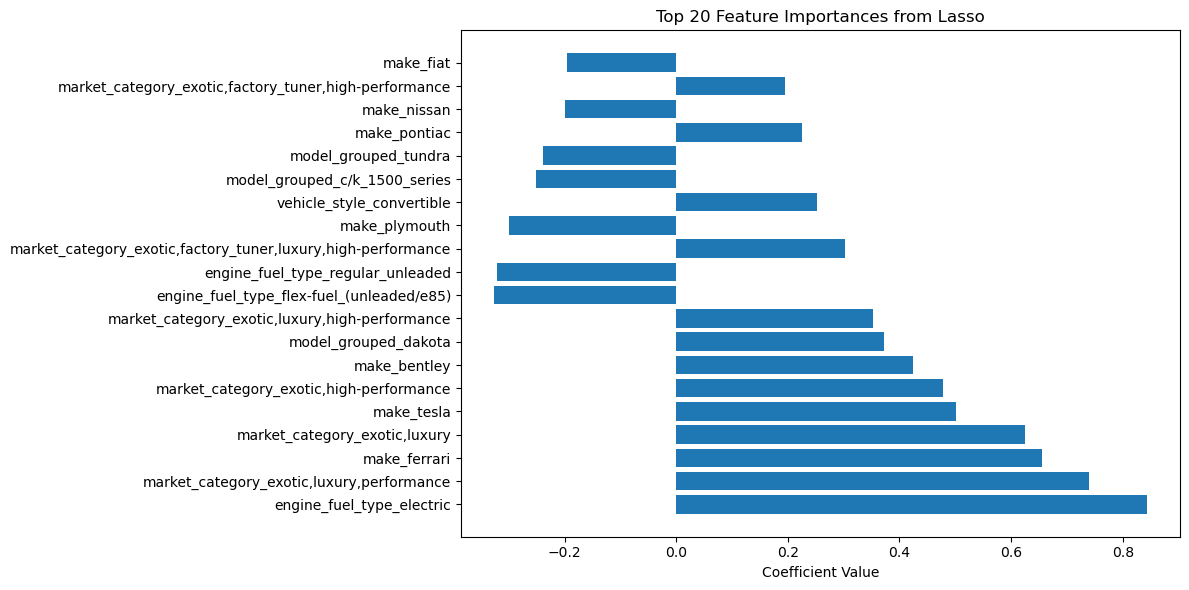

In [114]:
# 9. Visualize feature importance
plt.figure(figsize=(12, 6))
top_features = selected_features.head(20)
plt.barh(range(len(top_features)), top_features['coefficient'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Coefficient Value')
plt.title('Top 20 Feature Importances from Lasso')
plt.tight_layout()
plt.show()

In [432]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {'alpha': np.logspace(-3, 3, 50)}

# Create Ridge model
ridge = Ridge()

# Grid search with cross-validation
ridge_grid = GridSearchCV(
    ridge, 
    param_grid, 
    cv=5, 
    scoring='r2',
    verbose=1
)

# Fit the model
ridge_grid.fit(X_train, y_train)

# Results
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best R² score: {ridge_grid.best_score_}")

# Use the best model
best_ridge = ridge_grid.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best alpha: 0.28117686979742307
Best R² score: 0.871875468186658
